# 02 — Technical Analysis (EDA)

Tính các chỉ báo kỹ thuật (SMA, RSI, Volatility) và phân tích đặc điểm
thống kê của lợi nhuận cổ phiếu.

**Input**: `data/processed/stock_prices_clean.csv`
**Output**: `data/processed/stock_prices_features.csv`, biểu đồ trong `outputs/`

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import build_full_feature_set

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

df = pd.read_csv("../data/processed/stock_prices_clean.csv", parse_dates=["Date"])
df_feat = build_full_feature_set(df)
df_feat.tail()

,Date,Open,High,Low,Close,Volume,DailyReturn,LogReturn,SMA_20,SMA_50,Volatility,RSI
745,2024-11-11,219.2500,221.1000,217.7500,219.1200,4071953,-0.0030,-0.0030,213.5005,218.0476,0.2415,47.9860
746,2024-11-12,207.8200,209.2000,206.3600,207.4200,6755120,-0.0534,-0.0549,213.3750,218.0796,0.3117,39.1269
747,2024-11-13,203.2000,206.7700,200.5800,203.4300,5792841,-0.0192,-0.0194,212.9555,217.9984,0.3165,38.7788
748,2024-11-14,209.7700,211.6900,207.5300,209.9400,4566298,0.0320,0.0315,212.7815,218.0974,0.3373,48.2532
749,2024-11-15,214.8800,218.3900,210.3800,214.5900,4952307,0.0221,0.0219,212.7785,218.1900,0.3463,53.6232


## 1. Giá & Đường trung bình động (SMA)

SMA làm mượt nhiễu ngắn hạn để thấy rõ xu hướng — nền tảng cho chiến lược
giao dịch ở notebook 04.

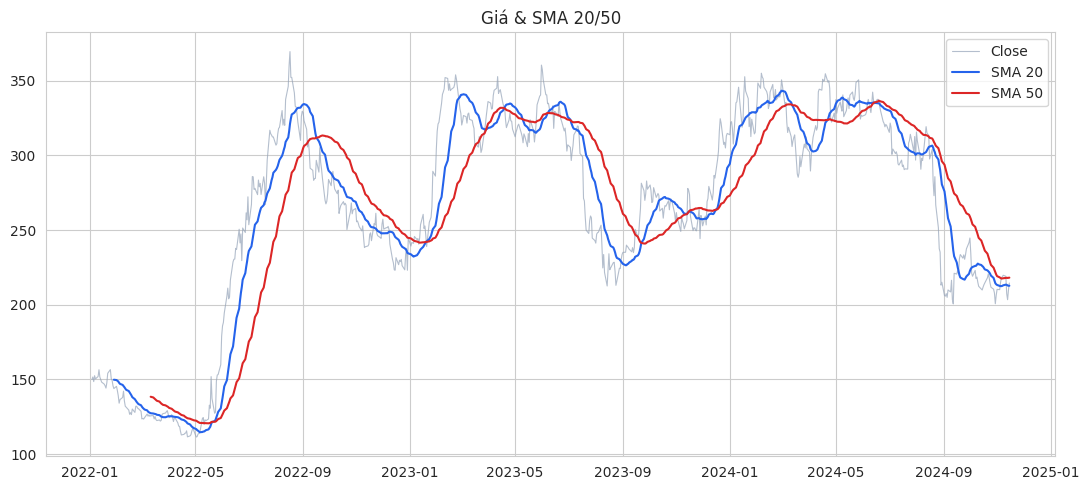

In [2]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df_feat["Date"], df_feat["Close"], color="#94a3b8", linewidth=0.8, label="Close", alpha=0.7)
ax.plot(df_feat["Date"], df_feat["SMA_20"], color="#2563eb", label="SMA 20")
ax.plot(df_feat["Date"], df_feat["SMA_50"], color="#dc2626", label="SMA 50")
ax.set_title("Giá & SMA 20/50")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/price_with_sma.png")
plt.show()

## 2. Phân bố lợi nhuận theo ngày (Daily Return)

Đặc điểm nổi tiếng của dữ liệu tài chính thật: phân bố lợi nhuận có "đuôi
dày" (fat tails) hơn phân phối chuẩn — các biến động cực đoan xảy ra thường
xuyên hơn so với dự đoán của phân phối chuẩn.

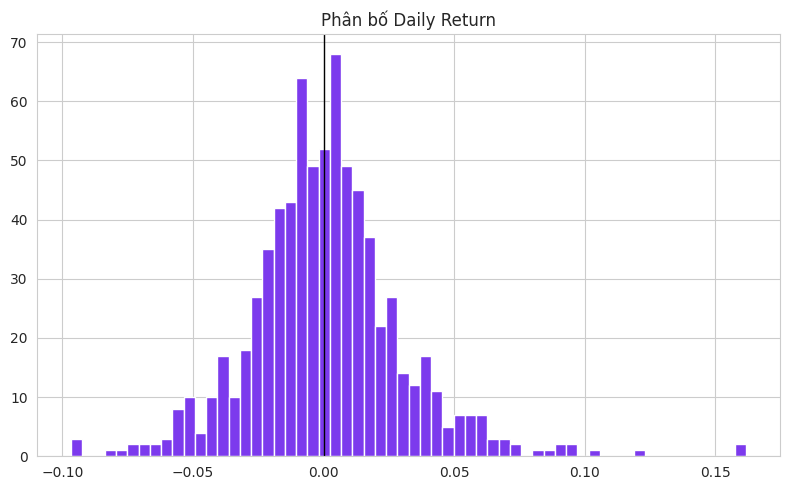

Mean: 0.00090
Std:  0.02919
Skewness: 0.620
Kurtosis: 3.259 (>0 nghĩa là đuôi dày hơn phân phối chuẩn)


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
df_feat["DailyReturn"].dropna().hist(bins=60, ax=ax, color="#7c3aed", edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Phân bố Daily Return")
plt.tight_layout()
plt.savefig("../outputs/return_distribution.png")
plt.show()

print(f"Mean: {df_feat['DailyReturn'].mean():.5f}")
print(f"Std:  {df_feat['DailyReturn'].std():.5f}")
print(f"Skewness: {df_feat['DailyReturn'].skew():.3f}")
print(f"Kurtosis: {df_feat['DailyReturn'].kurtosis():.3f} (>0 nghĩa là đuôi dày hơn phân phối chuẩn)")

## 3. Volatility Clustering — đặc điểm quan trọng của dữ liệu tài chính

Biến động có xu hướng "cụm lại" theo giai đoạn: giai đoạn biến động mạnh
thường đi liền với giai đoạn biến động mạnh khác, không phân bố ngẫu nhiên
đều theo thời gian.

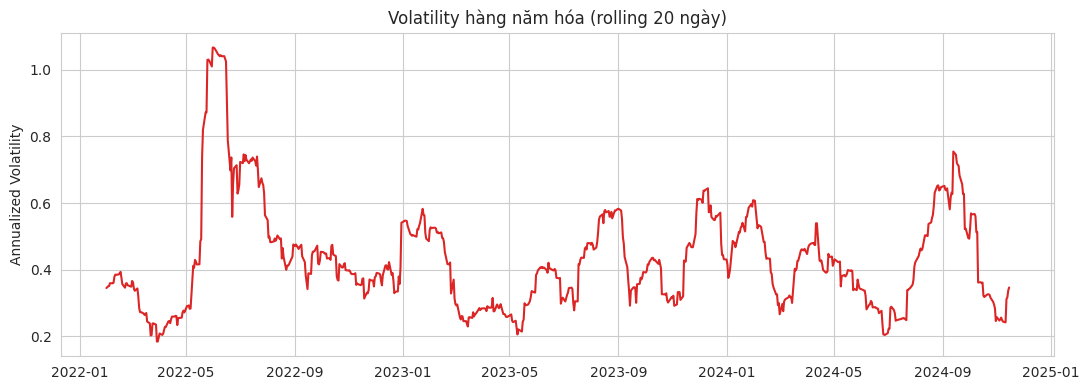

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df_feat["Date"], df_feat["Volatility"], color="#dc2626")
ax.set_title("Volatility hàng năm hóa (rolling 20 ngày)")
ax.set_ylabel("Annualized Volatility")
plt.tight_layout()
plt.savefig("../outputs/volatility.png")
plt.show()

**Nhận xét**: các giai đoạn volatility cao rõ rệt (nhìn thấy các "đỉnh")
xen kẽ giai đoạn ổn định — đúng đặc điểm volatility clustering, khác với
random walk thuần túy (nơi volatility không đổi theo thời gian).

## 4. RSI — chỉ báo momentum

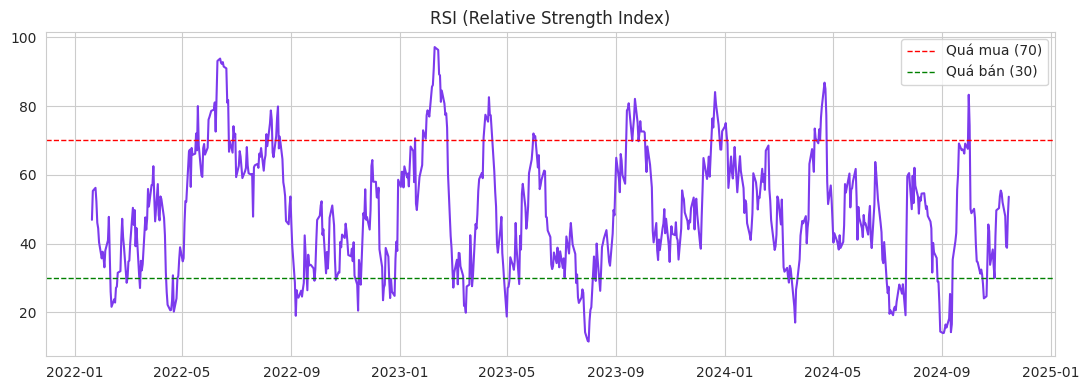

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df_feat["Date"], df_feat["RSI"], color="#7c3aed")
ax.axhline(70, color="red", linestyle="--", linewidth=1, label="Quá mua (70)")
ax.axhline(30, color="green", linestyle="--", linewidth=1, label="Quá bán (30)")
ax.set_title("RSI (Relative Strength Index)")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/rsi.png")
plt.show()

## 5. Kiểm tra tính dừng (Stationarity) — quan trọng cho ARIMA ở notebook 03

ARIMA giả định dữ liệu (sau khi lấy sai phân) có tính dừng. Kiểm định
Augmented Dickey-Fuller (ADF) để xác nhận.

In [6]:
from statsmodels.tsa.stattools import adfuller

adf_price = adfuller(df_feat["Close"].dropna())
adf_return = adfuller(df_feat["DailyReturn"].dropna())

print(f"ADF test - Giá gốc:    p-value = {adf_price[1]:.4f} {'(KHÔNG dừng)' if adf_price[1] > 0.05 else '(dừng)'}")
print(f"ADF test - Daily Return: p-value = {adf_return[1]:.4f} {'(KHÔNG dừng)' if adf_return[1] > 0.05 else '(dừng)'}")

ADF test - Giá gốc:    p-value = 0.3191 (KHÔNG dừng)
ADF test - Daily Return: p-value = 0.0000 (dừng)


**Nhận xét**: giá gốc thường KHÔNG có tính dừng (p-value > 0.05, có trend
rõ ràng), nhưng lợi nhuận (return) thường CÓ tính dừng — đây chính là lý do
ARIMA dùng tham số `d=1` (lấy sai phân bậc 1, tương đương chuyển giá thành
return) để đạt điều kiện tiên quyết trước khi mô hình hóa.

## 6. Lưu bộ feature

In [7]:
df_feat.to_csv("../data/processed/stock_prices_features.csv", index=False)
print("Đã lưu -> data/processed/stock_prices_features.csv")

Đã lưu -> data/processed/stock_prices_features.csv
